# 11. Categorical Features and Missing Values
@Shengli (Bruce) Jiang, University of South Carolina

Can catalyst composition and operating conditions help predict methanol production rate?

This notebook uses TheMeCat to prepare categorical and numerical inputs for a regression model.

## What We Have Covered

- Python, NumPy, pandas, functions, and plotting
- Linear and nonlinear regression
- Training, validation, and test data
- RMSE, MAE, and R-squared
- Ridge, Lasso, Elastic Net, cross-validation, and pipelines
- Scaling, nonlinear transformations, and engineered features

## What We Covered in the Last Lecture

We compared linear scaling with nonlinear transformations. StandardScaler changed units but preserved distribution shape. Yeo-Johnson changed the spacing between values and often reduced skewness. We also constructed polynomial terms, interactions, and physical ratios.

Every learned transformation was fitted on training data and reused for validation and test data.

## Today's Learning Objectives

By the end of this notebook, you should be able to:

1. Distinguish numerical, nominal, and ordinal features.
2. Use one-hot encoding without imposing a false order.
3. Choose a reasonable treatment for missing targets and missing inputs.
4. Combine imputation, encoding, and numerical transformation without data leakage.

## Running the notebook

Keep `TheMeCat_v1.csv` in the same folder as this notebook. Run the cells from top to bottom. Restart the kernel and run all cells when you finish.

The dataset comes from [Toldy et al., Scientific Data (2026)](https://doi.org/10.1038/s41597-025-06482-8) and is available from [Zenodo](https://doi.org/10.5281/zenodo.17085762).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("TheMeCat_v1.csv", na_values=["NA"])

blank_rows = df.isna().all(axis=1).sum()
df = df.dropna(how="all").copy()

print("Entirely blank rows removed:", blank_rows)
print("Remaining rows:", len(df))

Entirely blank rows removed: 303
Remaining rows: 821


## 1. Numerical and categorical features

A numerical feature represents a measured quantity. Its order and differences have meaning. For example, 600 K is hotter than 500 K, and the difference is 100 K.

A categorical feature identifies a group. `Cu`, `Pd`, and `In2O3` are material labels. Their order does not carry physical meaning.

**Discuss:** Reactor IDs `"523"` and `"072"` contain digits. Are they numerical or categorical?

They are categorical when the digits serve only as identifiers. Subtracting one reactor ID from another has no useful interpretation.

In [2]:
display(
    df[[
        "active_comp_1", "support_comp_1",
        "temperature_k", "pressure_bar"
    ]].head()
)

,active_comp_1,support_comp_1,temperature_k,pressure_bar
0,Cu,Al2O3,513.0,30.0
1,Cu,Al2O3,493.0,30.0
2,Cu,Al2O3,473.0,30.0
3,Cu,Al2O3,493.0,10.0
4,Cu,Al2O3,473.0,10.0


## 2. The TheMeCat regression problem

Each row represents an experimental result reported in the literature. The target is methanol space-time yield, or STY, measured per gram of catalyst per hour.

For this lesson, we use the first listed active component, the first listed support component, and four operating variables. This is a small teaching subset. It does not represent the complete catalyst composition, and the paper does not prescribe this exact set as an optimal machine-learning input set.

| Role | Dataset column | Meaning |
| :-- | :-- | :-- |
| Categorical input | `active_comp_1` | First active component listed in its reduced state |
| Categorical input | `support_comp_1` | First support component |
| Numerical input | `temperature_k` | Reaction temperature, K |
| Numerical input | `pressure_bar` | Reaction pressure, bar |
| Numerical input | `GHSV_nlph_gcat` | Gas hourly space velocity |
| Numerical input | `pH2_pCO2_ratio` | Hydrogen-to-carbon-dioxide feed ratio |
| Target | `STY_g_per_gcath` | Methanol STY per catalyst mass and time |

In [3]:
categorical_features = ["active_comp_1", "support_comp_1"]

numerical_features = [
    "temperature_k", "pressure_bar",
    "GHSV_nlph_gcat", "pH2_pCO2_ratio"
]

features = categorical_features + numerical_features
target = "STY_g_per_gcath"

display(
    df[[
        "active_comp_1", "support_comp_1",
        "temperature_k", "pressure_bar", target
    ]].head()
)

,active_comp_1,support_comp_1,temperature_k,pressure_bar,STY_g_per_gcath
0,Cu,Al2O3,513.0,30.0,0.1128
1,Cu,Al2O3,493.0,30.0,0.0944
2,Cu,Al2O3,473.0,30.0,0.0675
3,Cu,Al2O3,493.0,10.0,0.0462
4,Cu,Al2O3,473.0,10.0,0.0434


## 3. Inspecting the variables

Histograms show how often numerical values occur. Temperature and pressure cluster around common experimental settings. GHSV has a long right tail, while most reported feed ratios lie near 3.

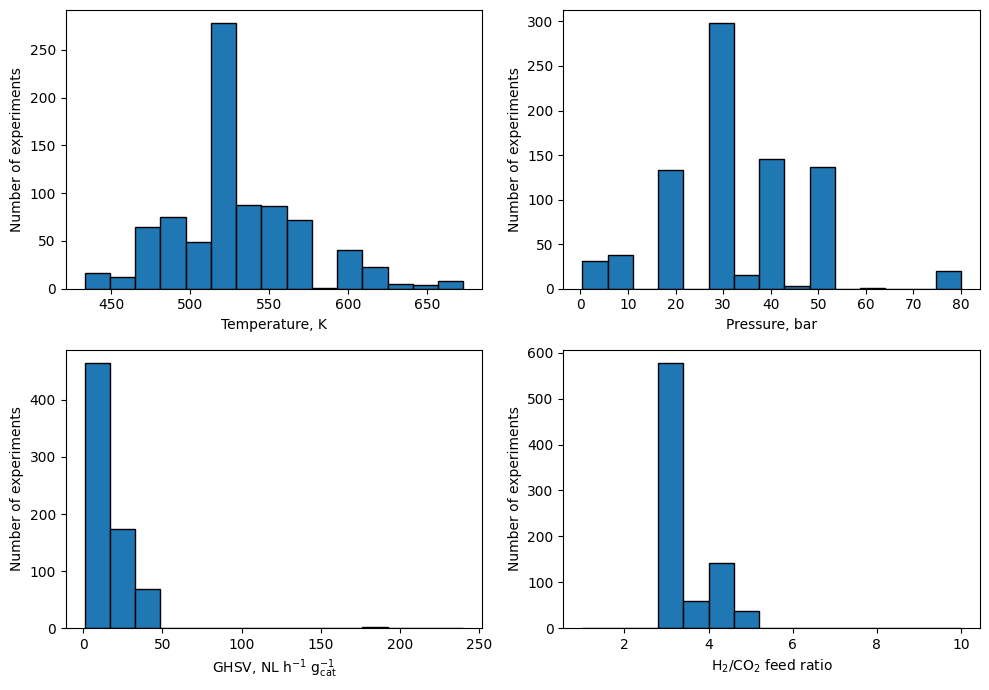

In [4]:
numerical_plots = [
    ("temperature_k", "Temperature, K"),
    ("pressure_bar", "Pressure, bar"),
    ("GHSV_nlph_gcat", r"GHSV, NL h$^{-1}$ g$_{\mathrm{cat}}^{-1}$"),
    ("pH2_pCO2_ratio", r"H$_2$/CO$_2$ feed ratio")
]

fig, ax = plt.subplots(2, 2, figsize=(10, 7))

for axis, (column, label) in zip(ax.flat, numerical_plots):
    axis.hist(df[column].dropna(), bins=15, color="C0", edgecolor="black")
    axis.set(xlabel=label, ylabel="Number of experiments")

fig.tight_layout()
plt.show()

The categorical counts are uneven. Cu appears far more often than several other active materials. Missing labels also occur, especially for the support component.

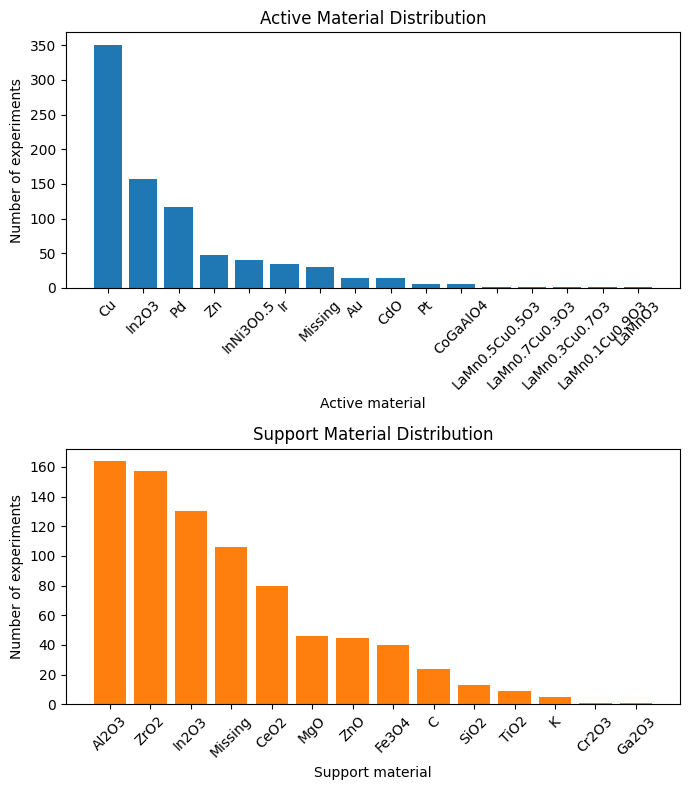

In [5]:
active_counts = df["active_comp_1"].fillna("Missing").value_counts()
support_counts = df["support_comp_1"].fillna("Missing").value_counts()

fig, ax = plt.subplots(2, 1, figsize=(7, 8))

ax[0].bar(active_counts.index, active_counts.values, color="C0")
ax[0].set(xlabel="Active material", ylabel="Number of experiments",
          title="Active Material Distribution")
ax[0].tick_params(axis="x", labelrotation=45)

ax[1].bar(support_counts.index, support_counts.values, color="C1")
ax[1].set(xlabel="Support material", ylabel="Number of experiments",
          title="Support Material Distribution")
ax[1].tick_params(axis="x", labelrotation=45)

fig.tight_layout()
plt.show()

### The target is right-skewed

Methanol STY includes zero values and has a long right tail. Yeo-Johnson can handle zeros and can reduce the skewness. The first plot below is descriptive. Later, the model will fit a new target transformer using only the training targets.

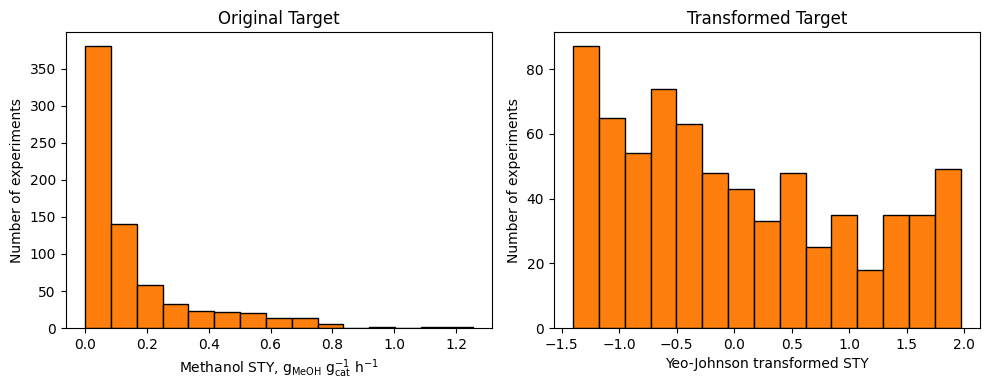

Original skewness: 2.061
Transformed skewness: 0.427


In [6]:
from sklearn.preprocessing import PowerTransformer

sty = df[[target]].dropna()
target_preview_transformer = PowerTransformer(method="yeo-johnson")
sty_transformed = target_preview_transformer.fit_transform(sty).ravel()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(sty[target], bins=15, color="C1", edgecolor="black")
ax[0].set(
    xlabel=r"Methanol STY, g$_{\mathrm{MeOH}}$ g$_{\mathrm{cat}}^{-1}$ h$^{-1}$",
    ylabel="Number of experiments",
    title="Original Target"
)

ax[1].hist(sty_transformed, bins=15, color="C1", edgecolor="black")
ax[1].set(
    xlabel="Yeo-Johnson transformed STY",
    ylabel="Number of experiments",
    title="Transformed Target"
)

fig.tight_layout()
plt.show()

print("Original skewness:", round(sty[target].skew(), 3))
print("Transformed skewness:", round(pd.Series(sty_transformed).skew(), 3))

## 4. One-hot encoding

Most scikit-learn estimators require numerical input. Assigning `Cu = 1`, `Pd = 2`, and `In2O3 = 3` would create an order and numerical distances that the material names do not have.

One-hot encoding creates one binary column for each category. A row receives 1 in the column for its category and 0 in the other category columns.

In [7]:
from sklearn.preprocessing import OneHotEncoder

example = pd.DataFrame({
    "active_comp_1": ["Cu", "Pd", "In2O3"]
})

encoder = OneHotEncoder(handle_unknown="ignore")
encoded = encoder.fit_transform(example).toarray()

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out()
)

display(example)
display(encoded_df.astype(int))
print("Learned category order:", encoder.categories_[0].tolist())

,active_comp_1
0,Cu
1,Pd
2,In2O3


,active_comp_1_Cu,active_comp_1_In2O3,active_comp_1_Pd
0,1,0,0
1,0,0,1
2,0,1,0


Learned category order: ['Cu', 'In2O3', 'Pd']


With `categories="auto"`, the encoder learns the unique training categories and orders strings lexicographically. The category order determines the output-column order.

By default, `OneHotEncoder` returns a SciPy sparse matrix. A sparse matrix stores the nonzero entries instead of storing every zero. We use `.toarray()` only when a small dense display is convenient.

### Categories absent from the training data

Suppose a new row contains `Au`, but the training example contains only `Cu`, `In2O3`, and `Pd`. With `handle_unknown="ignore"`, the active-material indicators for that row are all zero. The encoder does not create a new column at prediction time.

In [8]:
new_material = pd.DataFrame({"active_comp_1": ["Au"]})
new_encoded = encoder.transform(new_material).toarray()

display(
    pd.DataFrame(
        new_encoded,
        columns=encoder.get_feature_names_out()
    ).astype(int)
)

,active_comp_1_Cu,active_comp_1_In2O3,active_comp_1_Pd
0,0,0,0


### Encoding both material features

The full dataset contains 15 observed active-material categories and 13 observed support categories. Treating missing labels as an explicit category produces 30 one-hot columns. Each row has one active-material indicator and one support-material indicator equal to 1, so most entries are zero.

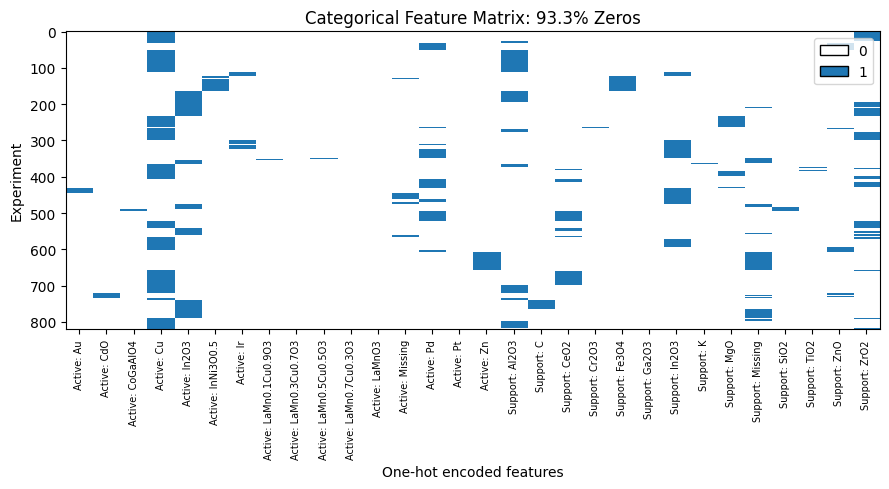

Original shape: (821, 2)
Encoded shape: (821, 30)


In [9]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

categorical_data = df[categorical_features].fillna("Missing")

categorical_encoder = OneHotEncoder()
categorical_encoded = categorical_encoder.fit_transform(
    categorical_data
).toarray()

names = categorical_encoder.get_feature_names_out()
names = [
    name.replace("active_comp_1_", "Active: ")
        .replace("support_comp_1_", "Support: ")
    for name in names
]

percent_zeros = 100 * (categorical_encoded == 0).mean()

fig, ax = plt.subplots(figsize=(9, 5))

ax.imshow(
    categorical_encoded,
    aspect="auto",
    interpolation="nearest",
    cmap=ListedColormap(["white", "C0"])
)

ax.set(
    xlabel="One-hot encoded features",
    ylabel="Experiment",
    title=f"Categorical Feature Matrix: {percent_zeros:.1f}% Zeros"
)

ax.set_xticks(range(len(names)), labels=names, rotation=90, fontsize=7)
ax.legend(
    handles=[
        Patch(facecolor="white", edgecolor="black", label="0"),
        Patch(facecolor="C0", edgecolor="black", label="1")
    ]
)

fig.tight_layout()
plt.show()

print("Original shape:", categorical_data.shape)
print("Encoded shape:", categorical_encoded.shape)

### Check your understanding

| Experiment | Active material | Support material |
| --: | :-- | :-- |
| 1 | Cu | Al2O3 |
| 2 | Pd | ZnO |
| 3 | Cu | ZnO |
| 4 | In2O3 | Al2O3 |

1. How many one-hot columns will these two features create?
2. Using the order `Active_Cu`, `Active_In2O3`, `Active_Pd`, `Support_Al2O3`, `Support_ZnO`, what is the encoded row for Experiment 2?
3. What percentage of each encoded row is zero?

**Answers**

1. Five columns: three active-material categories and two support categories.
2. Experiment 2 becomes `[0, 0, 1, 0, 1]`.
3. Three of the five values are zero, so each row is 60% zero.

## 5. Ordinal encoding

Ordinal encoding uses integers when the categories have a real ranking. For example, `Low`, `Medium`, and `High` describe ordered stability levels.

Active-material names do not have this kind of order, so one-hot encoding is more appropriate for `Cu`, `In2O3`, and `Pd`.

In [10]:
from sklearn.preprocessing import OrdinalEncoder

stability = pd.DataFrame({
    "stability": ["Low", "Medium", "High", "Medium"]
})

ordinal_encoder = OrdinalEncoder(
    categories=[["Low", "Medium", "High"]]
)

stability["stability_encoded"] = ordinal_encoder.fit_transform(
    stability[["stability"]]
).astype(int)

display(stability)

,stability,stability_encoded
0,Low,0
1,Medium,1
2,High,2
3,Medium,1


## 6. Missing values

An entirely blank row contains no experiment and can be removed. A row with no target cannot train a supervised regression model. A row with a missing input may still be useful if the missing input receives a defensible treatment.

We removed entirely blank rows when loading the file. The next comparison shows the selected columns before and after keeping only rows with observed STY.

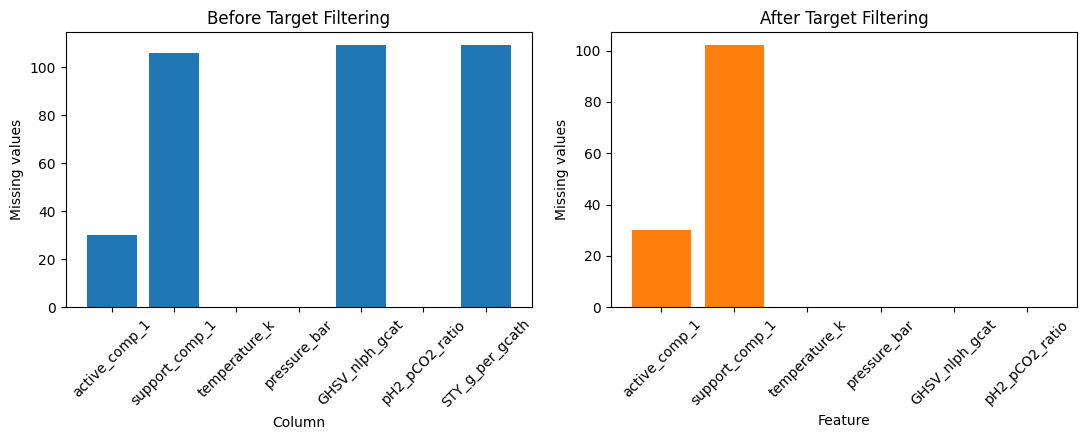

Rows available for supervised learning: 712


,missing_values
active_comp_1,30
support_comp_1,102
temperature_k,0
pressure_bar,0
GHSV_nlph_gcat,0
pH2_pCO2_ratio,0


In [11]:
missing_before = df[features + [target]].isna().sum()

model_df = df[features + [target]].dropna(subset=[target]).copy()
missing_after = model_df[features].isna().sum()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].bar(missing_before.index, missing_before.values, color="C0")
ax[0].set(
    xlabel="Column",
    ylabel="Missing values",
    title="Before Target Filtering"
)
ax[0].tick_params(axis="x", labelrotation=45)

ax[1].bar(missing_after.index, missing_after.values, color="C1")
ax[1].set(
    xlabel="Feature",
    ylabel="Missing values",
    title="After Target Filtering"
)
ax[1].tick_params(axis="x", labelrotation=45)

fig.tight_layout()
plt.show()

print("Rows available for supervised learning:", len(model_df))
display(missing_after.rename("missing_values").to_frame())

After target filtering, all four selected numerical inputs are complete. Missing values remain in the two material labels: 30 active materials and 102 support materials.

The following numerical example is therefore hypothetical. It shows what median imputation would do if a future dataset contained a missing temperature.

In [12]:
from sklearn.impute import SimpleImputer

temperature_example = pd.DataFrame({
    "temperature_k": [473.0, 493.0, np.nan, 523.0]
})

numeric_imputer = SimpleImputer(strategy="median")
temperature_example["temperature_imputed"] = numeric_imputer.fit_transform(
    temperature_example[["temperature_k"]]
).ravel()

display(temperature_example)
print("Training median:", numeric_imputer.statistics_[0], "K")

,temperature_k,temperature_imputed
0,473.0,473.0
1,493.0,493.0
2,NaN,493.0
3,523.0,523.0


Training median: 493.0 K


### Categorical imputation

For a material label, the most frequent category may be a poor assumption. Filling with the explicit label `"Missing"` preserves the fact that the source did not report a material.

The imputer must learn its behavior from the training data. We preview the operation here and place it inside the training pipeline later.

In [13]:
categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="Missing"
)

categorical_imputer.fit(model_df[categorical_features])

missing_examples = model_df.loc[
    model_df["support_comp_1"].isna(),
    categorical_features
].iloc[:4]

imputed_examples = categorical_imputer.transform(missing_examples)
imputed_examples = pd.DataFrame(
    imputed_examples,
    columns=categorical_features,
    index=missing_examples.index
)

display(missing_examples)
display(imputed_examples)

,active_comp_1,support_comp_1
212,In2O3,NaN
352,LaMn0.5Cu0.5O3,NaN
353,LaMn0.7Cu0.3O3,NaN
354,LaMn0.3Cu0.7O3,NaN


,active_comp_1,support_comp_1
212,In2O3,Missing
352,LaMn0.5Cu0.5O3,Missing
353,LaMn0.7Cu0.3O3,Missing
354,LaMn0.3Cu0.7O3,Missing


## 7. Leakage-safe preprocessing

The workflow is:

1. Keep rows with observed targets.
2. Split the rows into training, validation, and test data.
3. Fit imputers, encoders, and transformations on the training data.
4. Apply the fitted preprocessing to validation and test data without refitting.

This lesson uses a simple random 60/20/20 split. Several rows can come from the same publication. A research study should consider grouping rows by `reference` so experiments from one source do not appear in both training and test data.

In [14]:
from sklearn.model_selection import train_test_split

X = model_df[features]
y = model_df[target]

# Development: 80%, test: 20%
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=26
)

# Training: 60%, validation: 20%, test: 20%
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=26
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:", len(X_test))

Training rows: 426
Validation rows: 143
Test rows: 143


### Pipeline: steps in sequence

A `Pipeline` sends the output of one step to the next step. The categorical branch first replaces missing labels and then one-hot encodes the completed labels.

The numerical branch includes median imputation for robustness, even though the selected numerical columns are complete after target filtering. Yeo-Johnson then transforms and standardizes each numerical feature.

In [15]:
from sklearn.pipeline import Pipeline

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numerical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("transformer", PowerTransformer(method="yeo-johnson"))
])

### ColumnTransformer: different steps for different columns

`ColumnTransformer` applies the categorical pipeline to the material columns and the numerical pipeline to the operating-condition columns. It then combines both outputs into one feature matrix.

Only the training call uses `fit_transform`. Validation and test calls use `transform`.

In [16]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("categorical", categorical_preprocessor, categorical_features),
    ("numerical", numerical_preprocessor, numerical_features)
])

X_train_prepared = preprocessor.fit_transform(X_train)
X_val_prepared = preprocessor.transform(X_val)
X_test_prepared = preprocessor.transform(X_test)

print("Training:", X_train_prepared.shape)
print("Validation:", X_val_prepared.shape)
print("Test:", X_test_prepared.shape)

Training: (426, 33)
Validation: (143, 33)
Test: (143, 33)


The row counts stay the same. The number of columns grows because one-hot encoding replaces two categorical columns with separate binary columns. Validation and test matrices have the same columns learned from training data.

## 8. A Ridge regression baseline

This final calculation connects the preprocessing steps to a familiar regression model. We use a fixed Ridge alpha of 1.0. Hyperparameter selection is not part of this example.

The target receives its own Yeo-Johnson transformation fitted on `y_train`. Predictions are transformed back to the original STY scale before calculating RMSE and R-squared.

For this dataset, the fitted Yeo-Johnson inverse has a finite valid range. A linear model can predict outside that range. We bound transformed predictions to the transformed training-target range before applying the inverse. This also prevents the baseline from predicting beyond the observed training-target range.

In [17]:
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, r2_score

target_transformer = PowerTransformer(method="yeo-johnson")
y_train_transformed = target_transformer.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

model = Ridge(alpha=1.0)
model.fit(X_train_prepared, y_train_transformed)

y_val_pred_transformed = model.predict(X_val_prepared)
y_test_pred_transformed = model.predict(X_test_prepared)

lower = y_train_transformed.min()
upper = y_train_transformed.max()

y_val_pred_transformed = np.clip(y_val_pred_transformed, lower, upper)
y_test_pred_transformed = np.clip(y_test_pred_transformed, lower, upper)

y_val_pred = target_transformer.inverse_transform(
    y_val_pred_transformed.reshape(-1, 1)
).ravel()

y_test_pred = target_transformer.inverse_transform(
    y_test_pred_transformed.reshape(-1, 1)
).ravel()

print("Validation RMSE:", round(root_mean_squared_error(y_val, y_val_pred), 4))
print("Validation R2:", round(r2_score(y_val, y_val_pred), 4))
print("Test RMSE:", round(root_mean_squared_error(y_test, y_test_pred), 4))
print("Test R2:", round(r2_score(y_test, y_test_pred), 4))

Validation RMSE: 0.1238
Validation R2: 0.4789
Test RMSE: 0.1426
Test R2: 0.4027


### Test-set parity plot

The diagonal represents perfect agreement. Points below the diagonal are underpredictions. This modest baseline demonstrates the complete preprocessing workflow; its test score should not be used to choose another model and then report the same test set as independent evidence.

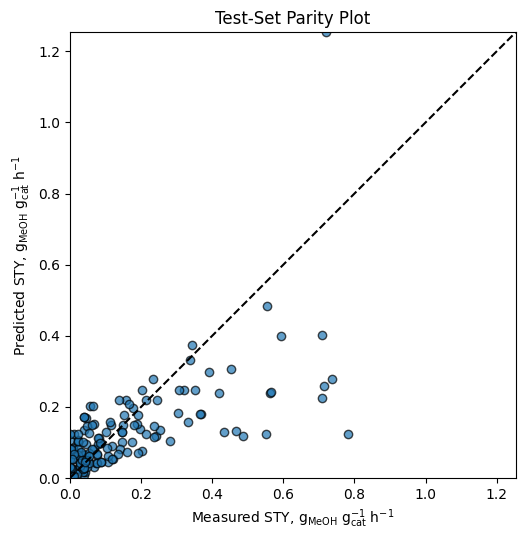

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

limits = [
    min(y_test.min(), y_test_pred.min()),
    max(y_test.max(), y_test_pred.max())
]

ax.scatter(
    y_test, y_test_pred,
    color="C0", edgecolor="black", alpha=0.7
)

ax.plot(limits, limits, "--", color="black")

ax.set(
    xlabel=r"Measured STY, g$_{\mathrm{MeOH}}$ g$_{\mathrm{cat}}^{-1}$ h$^{-1}$",
    ylabel=r"Predicted STY, g$_{\mathrm{MeOH}}$ g$_{\mathrm{cat}}^{-1}$ h$^{-1}$",
    title="Test-Set Parity Plot",
    xlim=limits,
    ylim=limits
)

ax.set_aspect("equal", adjustable="box")

fig.tight_layout()
plt.show()